In [2]:
import sys
sys.path.append('../')
import utils


import numpy as np
import scipy as sp
import utils.Camel.models as models
import utils.Camel.sampling as sampling
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import transforms

/home/mdrnevich/dev/QuasiML_paper/QuasiML/NegSampleStudy/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


# Generate and save some data

## Choose the parameters of the distributions

In [3]:
# target camel density
mixture_coef2 = (2, -1)  # coefficients of the pdf terms
scales2 = (2, 1.2)  # input scaling (x -> x/scale)

# sample size and train/val/test splits
N = int(1e7)
training_cutoff = int(0.5 * N) # 50%
validation_cutoff = int(0.65 * N) # 15%
testing_cutoff = int(1.0 * N) # 35%

SAVE_DATA = True

In [4]:
training_cutoff, validation_cutoff - training_cutoff, testing_cutoff - validation_cutoff

(5000000, 1500000, 3500000)

In [5]:
neg_mc_samples = sampling.sample_camel_mc(N, mixture_coef2, scales=scales2, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))

In [6]:
p_x = lambda x: models.camel_sampling_density(x[:,0], x[:,1], mixture_coef2, scales=scales2, basis="cartesian", logprob=False)
q_x = lambda x: models.camel_density(x[:,0], x[:,1], mixture_coef2, scales=scales2, basis="cartesian", logprob=False)
r_x = lambda x: q_x(x)/p_x(x)

In [7]:
target_weights = r_x(neg_mc_samples)
neg_mc_samples[:, -1] = target_weights

c = np.mean(np.heaviside(target_weights, 0)*target_weights)
c / (2*c-1)

0.9431895564513846

In [8]:
p_r = lambda t: models.camel_radial_density(t, mixture_coef, scales=scales, logprob=False) # look at the true radial densities
p_r2 = lambda t: models.camel_radial_density(t, mixture_coef2, scales=scales2, logprob=False) # look at the true radial densities
pos_p_r2 = lambda t: np.heaviside(p_r2(t), 0)*p_r2(t)

import scipy as sp
c = sp.integrate.quad(pos_p_r2, 0, int(1e1))[0]
c / (2*c - 1), N * (c-1) / (2*c-1)

(0.9432338600833424, 567661.3991665762)

In [9]:
# base/source density
mixture_coef = (c, 1-c)  # coefficients of the pdf terms
scales = (2.5, 2.3)  # input scaling (x -> x/scale)

mc_samples = sampling.sample_camel_mc(N, mixture_coef, scales=scales, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))

In [ ]:
if SAVE_DATA is True:
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data_train.npy', mc_samples[:training_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data_val.npy', mc_samples[training_cutoff:validation_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/base_distribution_data_test.npy', mc_samples[validation_cutoff:testing_cutoff])

In [131]:
if SAVE_DATA is True:
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data_train.npy', neg_mc_samples[:training_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data_val.npy', neg_mc_samples[training_cutoff:validation_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/target_distribution_data_test.npy', neg_mc_samples[validation_cutoff:testing_cutoff])

In [10]:
r = np.sqrt(mc_samples[:,0]**2 + mc_samples[:,1]**2)  # compute the radial coordinate
neg_r = np.sqrt(neg_mc_samples[:,0]**2 + neg_mc_samples[:,1]**2)  # compute the radial coordinate

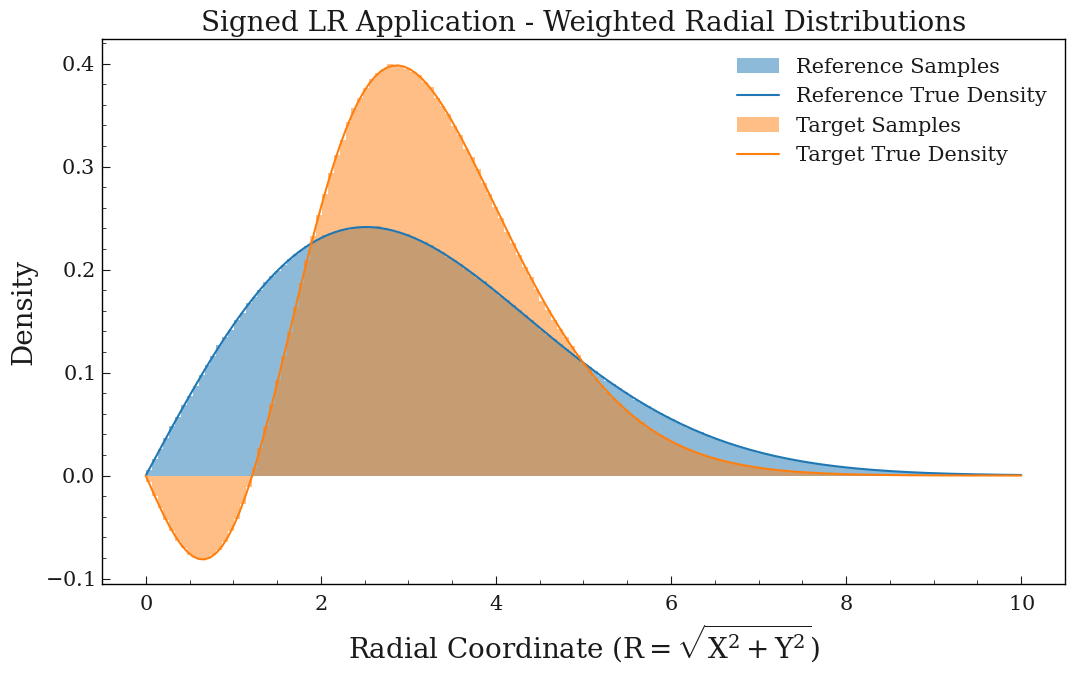

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(11,7)

xmax = 10  # boundary for plotting
t = np.linspace(0, xmax, 150)
p_r = models.camel_radial_density(t, mixture_coef, scales=scales, logprob=False) # look at the true radial densities
p_r2 = models.camel_radial_density(t, mixture_coef2, scales=scales2, logprob=False) # look at the true radial densities

bins = t
ax.hist(r, bins=bins, weights=mc_samples[:,-1], density=True, label="Reference Samples", color="tab:blue", alpha=0.5)
ax.plot(t, p_r, label="Reference True Density", color="tab:blue")
#ax.hist(neg_r, bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax.hist(neg_r, bins=bins, weights=neg_mc_samples[:,-1], density=True, label="Target Samples", color="tab:orange", alpha=0.5)
ax.plot(t, p_r2, label="Target True Density", color="tab:orange")

ax.set_xlabel("Radial Coordinate ($R = \sqrt{X^2+Y^2}$)", fontsize=20)
ax.set_ylabel("Density", fontsize=20)
ax.set_title("Signed LR Application - Weighted Radial Distributions", fontsize=20)
ax.legend(fontsize=15)

fig.tight_layout()
#fig.savefig("Toy_quasi_radial_distributions.pdf")

# Generate a grid of weight options as we vary the fraction of negative weights and the variance of the weights

## \begin{align*}
W &\sim 1 + \frac{1}{\sqrt{\eta(1-\eta)}}\left(\eta - \text{Bern}(\eta)\right) = 1 + \frac{1}{\sqrt{\eta(1-\eta)}}\left(\eta - H(\eta - \text{Unif}(0,1))\right) \\
\eta &\in \left(0, 1/2\right) \\
\mathbb{E}\left[W\right] &= \text{Var}(W) = 1 \\
\mathbb{E}\left[W^2 - W\right] &= 1
\end{align*}

In [12]:
#N_ETA = 50
#MIN_ETA = 0.01
#MAX_ETA = 0.5

N_POINTS = 50
MIN_SAMPLES = int(1e3)
MAX_SAMPLES = int(1e6)

#eta_arr = np.linspace(MIN_ETA, MAX_ETA, N_ETA)
#eta_arr

#sample_arr = np.linspace(MIN_SAMPLES, MAX_SAMPLES, N_POINTS)
sample_arr = np.logspace(3, 6, N_POINTS)

### Save the grid values for $\sigma, \eta$

In [13]:
np.save("sample_array.npy", sample_arr)

In [14]:
# How to get the weight from a random uniform sample
def weight_fn(u, eta, sigma=1):
    if eta == 0:
        return np.ones_like(u)
    return 1 + sigma*(eta - np.heaviside(eta - u, 1))/np.sqrt(eta*(1-eta))

## Look at the weights for an example choice of $\sigma, \eta$

In [15]:
w = weight_fn(np.random.random(N), 0.01)

In [16]:
w.min(), w.max()

(-8.9498743710662, 1.100503781525921)

In [17]:
w.mean(), w.var(), (w**2-w).mean()

(0.9996150705167541, 1.0037911649606037, 1.0034063836480678)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


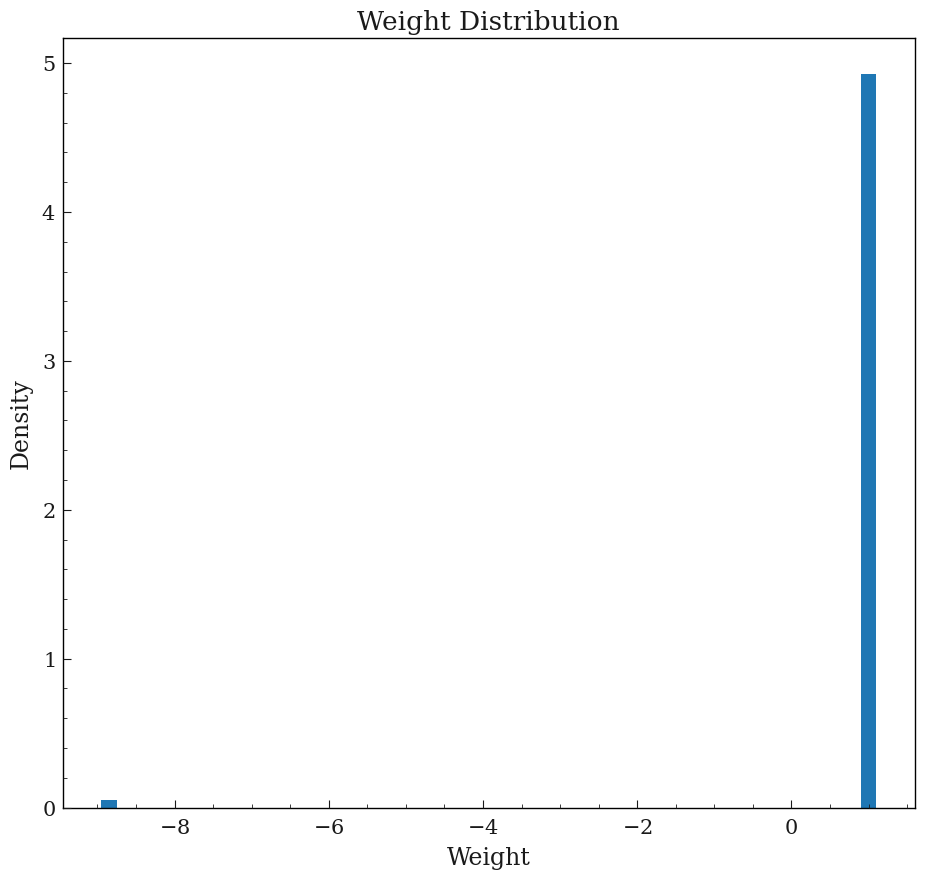

In [18]:
fig, ax = plt.subplots()
fig.set_size_inches(11,10)

ax.hist(w, bins=50, density=True, color="tab:blue", alpha=1)

ax.set_xlabel("Weight", fontsize=17)
ax.set_ylabel("Density", fontsize=17)
ax.set_title("Weight Distribution", fontsize="19")
ax.legend(fontsize=15)

#fig.savefig("../Toy_prob_radial_distributions.png")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


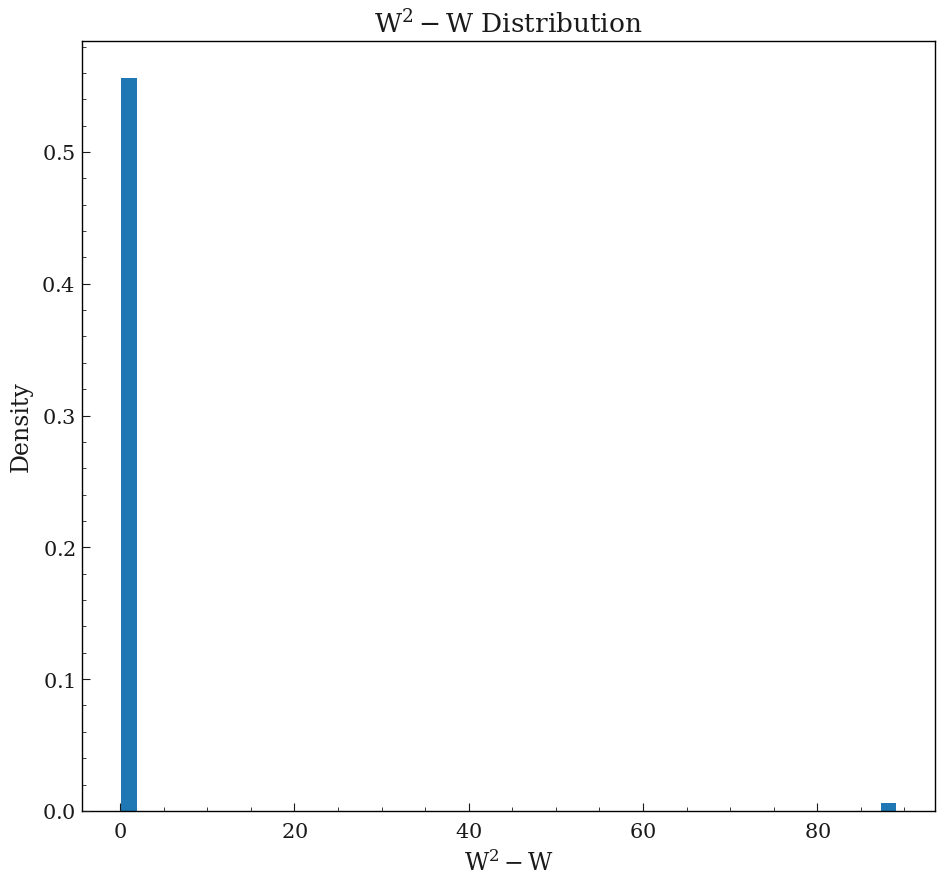

In [19]:
fig, ax = plt.subplots()
fig.set_size_inches(11,10)

#xmax = 10  # boundary for plotting
#bins = np.linspace(0, xmax, 150)

ax.hist(w**2-w, bins=50, density=True, color="tab:blue", alpha=1)

ax.set_xlabel(r"$W^2-W$", fontsize=17)
ax.set_ylabel("Density", fontsize=17)
ax.set_title(r"$W^2-W$ Distribution", fontsize="19")
ax.legend(fontsize=15)

#fig.savefig("../Toy_prob_radial_distributions.png")

## Save the weights generated at each point on the grid

In [138]:
weights = mc_samples[:,-1] #weight_fn(np.random.random(N), 0.01)
bool_arr = np.zeros_like(weights)
bool_arr[:] = False

for j in range(N_POINTS):
    bool_arr[np.random.choice(N, size=int(sample_arr[j]), replace=False)] = True
    w = np.where(bool_arr, weights, 0.0)
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/base_distribution_weights_sample_size{:d}_train.npy'.format(int(sample_arr[j])), w[:training_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/base_distribution_weights_sample_size{:d}_val.npy'.format(int(sample_arr[j])), w[training_cutoff:validation_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/base_distribution_weights_sample_size{:d}_test.npy'.format(int(sample_arr[j])), w[validation_cutoff:testing_cutoff])
    bool_arr[:] = False

In [139]:
weights = neg_mc_samples[:,-1] #weight_fn(np.random.random(N), 0.01)
bool_arr = np.zeros_like(weights)
bool_arr[:] = False

for j in range(N_POINTS):
    bool_arr[np.random.choice(N, size=int(sample_arr[j]), replace=False)] = True
    w = np.where(bool_arr, weights, 0.0)
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/target_distribution_weights_sample_size{:d}_train.npy'.format(int(sample_arr[j])), w[:training_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/target_distribution_weights_sample_size{:d}_val.npy'.format(int(sample_arr[j])), w[training_cutoff:validation_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/weights/target_distribution_weights_sample_size{:d}_test.npy'.format(int(sample_arr[j])), w[validation_cutoff:testing_cutoff])
    bool_arr[:] = False

In [20]:
for j in range(N_POINTS):
    sample_size = int(sample_arr[j])
    train_cutoff = int(0.5 * sample_size) # 50%
    val_cutoff = int(0.65 * sample_size) # 15%
    test_cutoff = int(1.0 * sample_size) # 35%

    mc_samples = sampling.sample_camel_mc(sample_size, mixture_coef, scales=scales, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))
    
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/base_distribution_sample_size{:d}_train.npy'.format(sample_size), mc_samples[:train_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/base_distribution_sample_size{:d}_val.npy'.format(sample_size), mc_samples[train_cutoff:val_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/base_distribution_sample_size{:d}_test.npy'.format(sample_size), mc_samples[val_cutoff:test_cutoff])

In [21]:
for j in range(N_POINTS):
    sample_size = int(sample_arr[j])
    train_cutoff = int(0.5 * sample_size) # 50%
    val_cutoff = int(0.65 * sample_size) # 15%
    test_cutoff = int(1.0 * sample_size) # 35%

    neg_mc_samples = sampling.sample_camel_mc(sample_size, mixture_coef2, scales=scales2, basis="cartesian", weight_scales=(1, 1), weight_spreads=(0, 0))
    target_weights = r_x(neg_mc_samples)
    neg_mc_samples[:, -1] = target_weights
    
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/target_distribution_sample_size{:d}_train.npy'.format(sample_size), neg_mc_samples[:train_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/target_distribution_sample_size{:d}_val.npy'.format(sample_size), neg_mc_samples[train_cutoff:val_cutoff])
    np.save('/data/mdrnevich/ml4nw/NegSampleStudy/data/target_distribution_sample_size{:d}_test.npy'.format(sample_size), neg_mc_samples[val_cutoff:test_cutoff])